# ML MVP - pierwsza iteracja

Ten notebook sprawdza pierwsze podejście ML do wyboru MVP. Nie mamy oficjalnych etykiet MVP, więc nie trenujemy modelu nadzorowanego. Zamiast tego używamy PCA, czyli metody nienadzorowanej, która szuka głównego wzorca różnicującego profile zawodników.

Porównujemy dwa podejścia:
- ręczny, interpretowalny `mvp_score`,
- nienadzorowany `ml_pca_score`.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root:", PROJECT_ROOT)


Project root: c:\Users\misie\Documents\UAM\MGR_MK


## Importy


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from mgr_mk.data_loader import load_world_cup_2018_matches
from mgr_mk.datasets import build_player_match_dataset
from mgr_mk.mvp import add_player_momentum_to_dataset, score_mvp_candidates, select_match_mvps
from mgr_mk.ml import (
    DEFAULT_ML_FEATURES,
    apply_pca_impact_model,
    compare_manual_and_ml_mvps,
    fit_pca_impact_model,
    select_ml_mvps,
)


## Konfiguracja

Domyślnie liczymy wszystkie mecze. Jeśli szybki test to `RUN_ALL_MATCHES = False`.


In [3]:
RUN_ALL_MATCHES = True
NUMBER_OF_MATCHES_FOR_TEST = 10

MIN_MINUTES_FOR_MVP = 30
FULL_MINUTES_REFERENCE = 60


## Budowa datasetu i ręcznego rankingu MVP


In [4]:
df_matches = load_world_cup_2018_matches()

if RUN_ALL_MATCHES:
    match_ids = df_matches["match_id"].tolist()
else:
    match_ids = df_matches.head(NUMBER_OF_MATCHES_FOR_TEST)["match_id"].tolist()

player_match_dataset = build_player_match_dataset(df_matches, match_ids=match_ids)
player_match_dataset = add_player_momentum_to_dataset(player_match_dataset, df_matches)

mvp_candidates = score_mvp_candidates(
    player_match_dataset,
    min_minutes=MIN_MINUTES_FOR_MVP,
    full_minutes_reference=FULL_MINUTES_REFERENCE,
)
manual_mvps = select_match_mvps(mvp_candidates)

print("Liczba meczów:", len(match_ids))
print("Liczba wierszy zawodnik-mecz:", len(mvp_candidates))
manual_mvps.head(10)


Liczba meczów: 64
Liczba wierszy zawodnik-mecz: 1787


,match_id,match_date,competition_stage,player.name,team.name,opponent,result,minutes_played,player_momentum,mvp_score,mvp_rank_all_players,mvp_rank_eligible,is_mvp_eligible
0,8650,2018-07-06,Quarter-finals,Philippe Coutinho Correia,Brazil,Belgium,loss,95.0,12.724406,0.655900,1.0,1.0,True
1,7584,2018-07-02,Round of 16,Jan Vertonghen,Belgium,Japan,win,90.0,18.290501,0.711384,1.0,1.0,True
2,7554,2018-06-24,Group Stage,Harry Kane,England,Panama,win,60.0,45.500000,0.725121,1.0,1.0,True
3,7539,2018-06-19,Group Stage,M'Baye Babacar Niang,Senegal,Poland,win,75.0,18.600000,0.782915,1.0,1.0,True
4,7550,2018-06-22,Group Stage,Xherdan Shaqiri,Switzerland,Serbia,win,96.0,27.672862,0.778025,1.0,1.0,True
5,7538,2018-06-18,Group Stage,Andreas Granqvist,Sweden,South Korea,win,93.0,21.847219,0.799173,1.0,1.0,True
6,7534,2018-06-17,Group Stage,Hirving Rodrigo Lozano Bahena,Mexico,Germany,win,66.0,18.259643,0.725885,1.0,1.0,True
7,7543,2018-06-20,Group Stage,David Josué Jiménez Silva,Spain,Iran,win,94.0,12.299551,0.634436,1.0,1.0,True
8,7544,2018-06-20,Group Stage,Luis Alberto Suárez Díaz,Uruguay,Saudi Arabia,win,94.0,22.370683,0.665148,1.0,1.0,True
9,7546,2018-06-21,Group Stage,Kylian Mbappé Lottin,France,Peru,win,74.0,20.028664,0.820675,1.0,1.0,True


## PCA jako pierwszy model ML

PCA bierze kilka cech profilu zawodnika i znajduje pierwszy główny kierunek zmienności. Interpretujemy go jako alternatywny, nienadzorowany wskaźnik wpływu zawodnika na mecz.


In [5]:
print("Cechy użyte w PCA:")
for feature in DEFAULT_ML_FEATURES:
    print("-", feature)

pca_model = fit_pca_impact_model(mvp_candidates, features=DEFAULT_ML_FEATURES, n_components=2)
ml_candidates = apply_pca_impact_model(mvp_candidates, pca_model)
ml_mvps = select_ml_mvps(ml_candidates)

print("Explained variance ratio:", pca_model["explained_variance_ratio"])
ml_mvps.head(10)


Cechy użyte w PCA:
- norm_player_momentum
- attacking_component
- involvement_component
- defending_component
- result_score
- minute_factor
Explained variance ratio: [0.44143311 0.20025202]


,match_id,match_date,competition_stage,player.name,team.name,opponent,result,minutes_played,mvp_score,ml_pca_score,mvp_rank_eligible,ml_rank_eligible,is_mvp_eligible
0,8650,2018-07-06,Quarter-finals,Philippe Coutinho Correia,Brazil,Belgium,loss,95.0,0.655900,1.0,1.0,1.0,True
1,7584,2018-07-02,Round of 16,Jan Vertonghen,Belgium,Japan,win,90.0,0.711384,1.0,1.0,1.0,True
2,7554,2018-06-24,Group Stage,Harry Kane,England,Panama,win,60.0,0.725121,1.0,1.0,1.0,True
3,7539,2018-06-19,Group Stage,M'Baye Babacar Niang,Senegal,Poland,win,75.0,0.782915,1.0,1.0,1.0,True
4,7550,2018-06-22,Group Stage,Xherdan Shaqiri,Switzerland,Serbia,win,96.0,0.778025,1.0,1.0,1.0,True
5,7538,2018-06-18,Group Stage,Andreas Granqvist,Sweden,South Korea,win,93.0,0.799173,1.0,1.0,1.0,True
6,7534,2018-06-17,Group Stage,Toni Kroos,Germany,Mexico,loss,94.0,0.671983,1.0,2.0,1.0,True
7,7543,2018-06-20,Group Stage,Francisco Román Alarcón Suárez,Spain,Iran,win,95.0,0.613919,1.0,2.0,1.0,True
8,7544,2018-06-20,Group Stage,Luis Alberto Suárez Díaz,Uruguay,Saudi Arabia,win,94.0,0.665148,1.0,1.0,1.0,True
9,7546,2018-06-21,Group Stage,Kylian Mbappé Lottin,France,Peru,win,74.0,0.820675,1.0,1.0,1.0,True


## Jak PCA waży cechy?

Tabela pokazuje ładunki pierwszych dwóch komponentów. Dodatnie wartości w `PC1` zwiększają `ml_pca_score`.


In [6]:
loadings = pd.DataFrame({
    "feature": pca_model["features"],
    "PC1_loading": pca_model["components"][0],
    "PC2_loading": pca_model["components"][1] if len(pca_model["components"]) > 1 else 0,
})
loadings.sort_values("PC1_loading", ascending=False)


,feature,PC1_loading,PC2_loading
2,involvement_component,0.512360,-0.244170
1,attacking_component,0.488286,0.374778
5,minute_factor,0.464669,-0.359535
0,norm_player_momentum,0.414437,0.533372
3,defending_component,0.329592,-0.413387
4,result_score,0.052521,0.463986


## Porównanie ręcznego MVP i ML MVP

Jeśli oba podejścia wybierają tego samego zawodnika, wynik jest stabilny. Jeśli nie, mecz jest ciekawym przypadkiem do interpretacji.


In [7]:
mvp_comparison = compare_manual_and_ml_mvps(manual_mvps, ml_mvps)

agreement_rate = mvp_comparison["same_player"].mean()
print(f"Zgodność ręcznego MVP i ML MVP: {agreement_rate:.1%}")

mvp_comparison.head(20)


Zgodność ręcznego MVP i ML MVP: 85.9%


,match_id,manual_mvp_player,manual_mvp_team,manual_mvp_score,ml_mvp_player,ml_mvp_team,ml_mvp_score,same_player
0,8650,Philippe Coutinho Correia,Brazil,0.655900,Philippe Coutinho Correia,Brazil,1.0,True
1,7584,Jan Vertonghen,Belgium,0.711384,Jan Vertonghen,Belgium,1.0,True
2,7554,Harry Kane,England,0.725121,Harry Kane,England,1.0,True
3,7539,M'Baye Babacar Niang,Senegal,0.782915,M'Baye Babacar Niang,Senegal,1.0,True
4,7550,Xherdan Shaqiri,Switzerland,0.778025,Xherdan Shaqiri,Switzerland,1.0,True
5,7538,Andreas Granqvist,Sweden,0.799173,Andreas Granqvist,Sweden,1.0,True
6,7534,Hirving Rodrigo Lozano Bahena,Mexico,0.725885,Toni Kroos,Germany,1.0,False
7,7543,David Josué Jiménez Silva,Spain,0.634436,Francisco Román Alarcón Suárez,Spain,1.0,False
8,7544,Luis Alberto Suárez Díaz,Uruguay,0.665148,Luis Alberto Suárez Díaz,Uruguay,1.0,True
9,7546,Kylian Mbappé Lottin,France,0.820675,Kylian Mbappé Lottin,France,1.0,True


## Mecze, w których metody się różnią


In [8]:
disagreements = mvp_comparison[~mvp_comparison["same_player"]].copy()
disagreements.head(20)


,match_id,manual_mvp_player,manual_mvp_team,manual_mvp_score,ml_mvp_player,ml_mvp_team,ml_mvp_score,same_player
6,7534,Hirving Rodrigo Lozano Bahena,Mexico,0.725885,Toni Kroos,Germany,1.0,False
7,7543,David Josué Jiménez Silva,Spain,0.634436,Francisco Román Alarcón Suárez,Spain,1.0,False
19,7557,Ricardo Andrade Quaresma Bernardo,Portugal,0.628171,Adrien Sebastian Perruchet Silva,Portugal,1.0,False
25,7536,Romelu Lukaku Menama,Belgium,0.652470,Dries Mertens,Belgium,1.0,False
30,7537,Harry Kane,England,0.646067,John Stones,England,1.0,False
33,7549,Ahmed Musa,Nigeria,0.718871,Gylfi Þór Sigurðsson,Iceland,1.0,False
56,7567,Heung-Min Son,South Korea,0.707724,Toni Kroos,Germany,1.0,False
59,8657,Eden Hazard,Belgium,0.743768,Eric Dier,England,1.0,False
62,7556,Sadio Mané,Senegal,0.654265,M'Baye Babacar Niang,Senegal,1.0,False


## Ranking dla wybranego meczu



In [9]:
SELECTED_MATCH_ID = match_ids[10]

columns_to_show = [
    "match_id",
    "player.name",
    "team.name",
    "minutes_played",
    "is_mvp_eligible",
    "mvp_score",
    "ml_pca_score",
    "mvp_rank_eligible",
    "ml_rank_eligible",
    "player_momentum",
    "attacking_component",
    "involvement_component",
    "defending_component",
]

ml_candidates[ml_candidates["match_id"].eq(SELECTED_MATCH_ID)][columns_to_show].sort_values(
    "ml_rank_eligible"
).head(15)


,match_id,player.name,team.name,minutes_played,is_mvp_eligible,mvp_score,ml_pca_score,mvp_rank_eligible,ml_rank_eligible,player_momentum,attacking_component,involvement_component,defending_component
288,7545,Ivan Rakitić,Croatia,95.0,True,0.742404,1.000000,1.0,1.0,21.532052,0.715148,0.565469,0.336820
293,7545,Maximiliano Eduardo Meza,Argentina,95.0,True,0.507830,0.889207,5.0,2.0,7.584484,0.583326,0.697956,0.660819
285,7545,Ante Rebić,Croatia,57.0,True,0.630466,0.862835,2.0,3.0,17.950036,0.718836,0.325012,0.293198
284,7545,Luka Modrić,Croatia,91.0,True,0.627195,0.853719,3.0,4.0,20.042896,0.330614,0.646833,0.262539
289,7545,Mario Mandžukić,Croatia,93.0,True,0.519711,0.839061,4.0,5.0,8.219618,0.547197,0.495312,0.668275
299,7545,Enzo Nicolás Pérez,Argentina,67.0,True,0.433376,0.810651,6.0,6.0,5.218649,0.582745,0.814489,0.266424
296,7545,Nicolás Alejandro Tagliafico,Argentina,94.0,True,0.400572,0.777889,7.0,7.0,4.350000,0.333333,0.939024,0.391503
275,7545,Nicolás Hernán Otamendi,Argentina,93.0,True,0.374118,0.747093,8.0,8.0,3.539798,0.386411,0.864858,0.313367
294,7545,Lionel Andrés Messi Cuccittini,Argentina,94.0,True,0.346382,0.672360,9.0,9.0,5.844755,0.366802,0.581554,0.289098
295,7545,Javier Alejandro Mascherano,Argentina,95.0,True,0.310947,0.662974,12.0,10.0,2.850000,0.194280,0.781602,0.398201


## Wykres: ręczny score vs ML score

Każda kropka to zawodnik-mecz. Jeżeli punkty układają się rosnąco, PCA jest podobne do naszego ręcznego score'u.


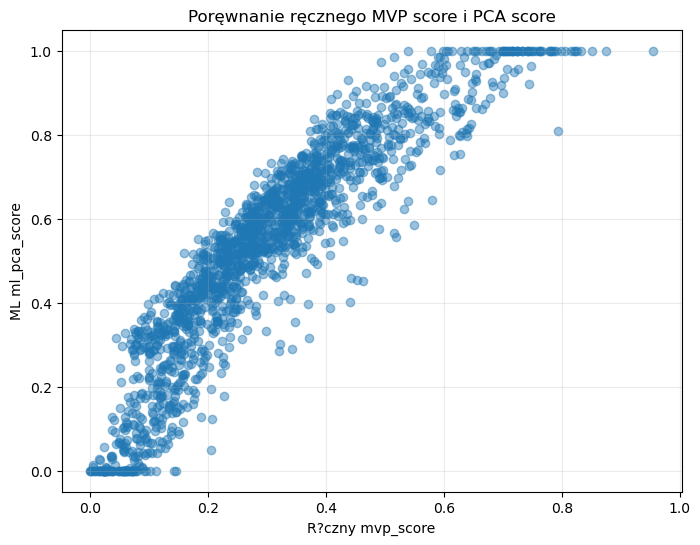

In [11]:
plot_data = ml_candidates.copy()

plt.figure(figsize=(8, 6))
plt.scatter(plot_data["mvp_score"], plot_data["ml_pca_score"], alpha=0.45)
plt.xlabel("R?czny mvp_score")
plt.ylabel("ML ml_pca_score")
plt.title("Poręwnanie ręcznego MVP score i PCA score")
plt.grid(alpha=0.25)
plt.show()


## Wykres PCA: profil zawodników

PC1 jest używany jako `ml_pca_score`. PC2 pokazuje drugi wymiar profilu, np. różnicę między profilem ofensywnym i defensywnym, zależnie od ładunków cech.


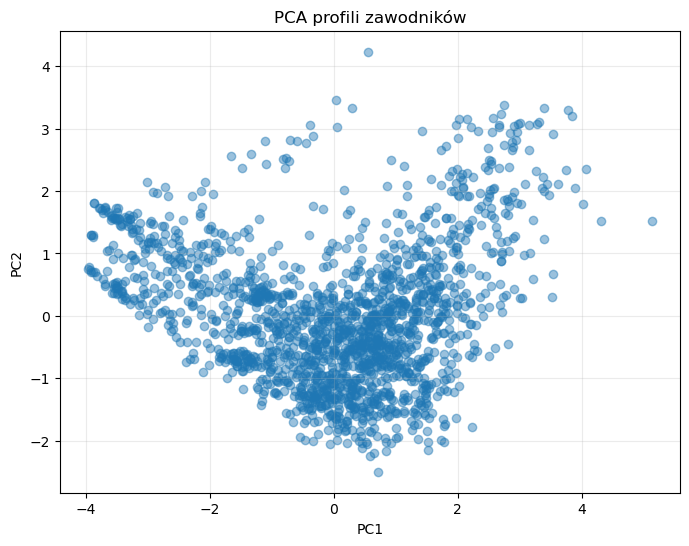

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(ml_candidates["ml_pc1"], ml_candidates["ml_pc2"], alpha=0.45)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA profili zawodników")
plt.grid(alpha=0.25)
plt.show()
